# Lenacapavir PBPK — Whole-Body Mass Balance ([¹⁴C] Radioactivity)
**Study:** Cohort 2 · 20 mg IV · N = 10  
**Model:** 3-compartment liver (series) · 2 peripheral tissues · biliary + renal excretion  
**Substrate (S):** LEN parent · **Product (P):** lumped metabolites  
**Optimizer:** `dual_annealing` with KeyboardInterrupt recovery · p-norm (p=4) on 4 main observables · urine as soft penalty
P-norm was considered as good compromise exhibiting some properties of max() function, to ensure whole system fitting, not some data subset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.optimize import dual_annealing
from IPython.display import clear_output
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [3]:
# ── Drug ──────────────────────────────────────────────────────────────────────
MW_S    = 1278.8   # g/mol  LEN free acid
Dose_mg = 20.0     # mg     IV bolus (Cohort 2)
fup_S   = 0.002    # fraction unbound in plasma, substrate
RBP_S   = 0.64     # blood-to-plasma ratio, substrate (literature)
# fup_P and RBP_P are FITTED — product is a mixture of metabolites

# ── Physiology (human) ────────────────────────────────────────────────────────
Qh    = 90.0    # L/h  hepatic blood flow
QT1   = 100.0   # L/h  peripheral tissue 1
QT2   = 110.0   # L/h  peripheral tissue 2
Q_CO  = Qh + QT1 + QT2

V_art = 0.8     # L
V_ven = 4.0     # L
V_L   = 1.5     # L  (3 sub-compartments of V_L/3 each)
V_T1  = 2.0     # L
V_T2  = 8.0     # L
VL3   = V_L / 3

# ── Dose → initial conditions ─────────────────────────────────────────────────
Dose_mmol   = Dose_mg / MW_S           # mmol
C0_blood_S  = Dose_mmol / V_ven        # mmol/L  (IV bolus into venous compartment)
C0_plasma_S = C0_blood_S / RBP_S       # mmol/L  plasma (theoretical t=0)

print(f"Dose          = {Dose_mg} mg = {Dose_mmol*1e6:.2f} nmol")
print(f"C0 blood  (S) = {C0_blood_S  * MW_S * 1e3:.1f} ng-eq/mL")
print(f"C0 plasma (S) = {C0_plasma_S * MW_S * 1e3:.1f} ng/mL")


Dose          = 20.0 mg = 15639.66 nmol
C0 blood  (S) = 5000.0 ng-eq/mL
C0 plasma (S) = 7812.5 ng/mL


In [ ]:
# ── Experimental data — 20 mg IV lenacapavir (Cohort 2, 14C-ADME) ────────────
# Digitized from published figures.  Time in hours.
# t=0 prepended to each observable:
#   plasma/blood/LEN: C0 from constants (product=0 at t=0)
#   feces/urine:      0% (accumulators start at zero)

# 1. [14C] Plasma TRA  (ng-eq/mL)
t_pTRA = np.concatenate([[0.0], [
    0.9832,   1.9916,   4.0084,   6.0000,   8.0168,  11.9999,
   24.0252,  47.0400,  73.9200, 118.7199, 168.0000, 215.0400,
  264.3200, 336.0001, 506.2401, 674.2401, 842.2401,1012.4801,
]])
obs_pTRA = np.concatenate([[C0_plasma_S * MW_S * 1e3], [
  251.688,  63.347,  32.257,  23.248,  22.343,  13.468,
   14.581,  12.086,  13.780,  10.447,  10.756,   9.713,
    9.163,   8.519,   7.152,   6.649,   5.190,   4.968,
]])

# 2. [14C] Blood TRA  (ng-eq/mL)
t_bTRA = np.concatenate([[0.0], [
    0.9787,   1.9787,   3.9787,   5.9787,   8.0000,  11.9999,
   24.0425,  47.3239,  70.9859, 168.0000, 220.0562, 265.0140,
  338.3660,
]])
obs_bTRA = np.concatenate([[C0_blood_S * MW_S * 1e3], [
  148.010,  34.374,  17.343,  11.524,  12.115,   8.393,
    8.750,   8.725,   8.994,   8.465,   8.089,   6.952,
    7.613,
]])

# 3. [LEN] Plasma parent  (ng/mL)
t_LEN = np.concatenate([[0.0], [
    0.9787,   1.9787,   4.0000,   5.9787,   8.0000,  12.0213,
   24.0425,  44.9577,  70.9859, 120.6761, 168.0000, 217.6900,
  267.3802, 338.3660, 511.0983, 679.0983, 849.4644,1019.8305,
 1192.5627,1362.9288,1530.9288,1701.2950,1874.0272,2042.0270,
 2382.7592,
]])
obs_LEN = np.concatenate([[C0_plasma_S * MW_S * 1e3], [
  206.641,  47.592,  23.031,  14.678,  23.419,   8.678,
    8.393,   7.613,   7.967,   6.348,   6.643,   5.374,
    4.833,   4.549,   2.888,   2.520,   1.375,   1.199,
    0.706,   0.476,   0.379,   0.264,   0.220,   0.256,
    0.158,
]])

# 4. Feces cumulative  (% dose)
t_fec = np.concatenate([[0.0], [
   20.452,  43.826,  73.043,  96.417, 116.870, 143.165,
  166.539, 189.913, 216.209, 236.661, 262.957, 286.330,
  312.626, 336.000, 359.374, 385.670, 409.043, 432.417,
  455.791, 479.165, 502.539, 531.757, 552.209, 581.426,
  604.800, 625.252, 648.626, 674.922, 698.296, 721.670,
  747.965, 771.339, 797.635, 818.087, 841.461, 867.757,
  891.130, 917.426, 940.800, 967.096, 987.548,1010.922,
 1037.217,1063.513,1086.887,1110.261,1133.635,1151.165,
 1180.383,1206.678,1230.052,1256.348,1279.722,1303.096,
 1329.391,1358.609,1384.904,1431.652,1469.635,1498.852,
 1522.226,1545.600,1571.895,1595.269,1615.722,1642.018,
 1665.391,1685.844,1712.139,1738.435,1764.730,1788.104,
 1808.556,1834.852,1861.148,1881.600,1907.895,1931.269,
 1951.722,1978.017,2004.313,2027.687,
]])
obs_fec = np.concatenate([[0.0], [
    0.171,   2.393,   4.786,   9.231,  12.991,  16.410,
   19.829,  23.761,  26.838,  28.718,  32.650,  35.385,
   38.291,  40.171,  42.735,  44.274,  47.009,  48.889,
   51.282,  52.308,  54.017,  56.752,  58.632,  59.829,
   60.684,  61.709,  62.906,  63.590,  63.248,  64.786,
   65.470,  66.154,  67.009,  67.692,  68.376,  69.060,
   69.744,  70.598,  70.940,  71.453,  71.966,  72.820,
   73.333,  73.504,  74.359,  74.359,  74.872,  75.385,
   75.555,  75.726,  76.239,  76.581,  76.923,  77.094,
   77.607,  77.778,  78.291,  78.291,  78.632,  78.974,
   79.145,  79.145,  79.487,  80.000,  79.658,  80.000,
   79.829,  80.171,  80.513,  80.684,  80.684,  80.513,
   80.513,  80.684,  80.855,  81.026,  81.026,  81.538,
   81.368,  81.197,  81.197,  81.538,
]])

# 5. Urine cumulative  (% dose)
t_uri = np.concatenate([[0.0], [
    2.922,  26.296,  49.670,  73.043,  99.339, 143.165,
  239.583, 432.417, 578.504, 698.296, 818.087,1016.765,
]])
obs_uri = np.concatenate([[0.0], [
    0.171,   0.342,   0.342,   0.342,   0.342,   0.342,
    0.342,   0.342,   0.342,   0.513,   0.342,   0.513,
]])

T_MAX_H = max(t_LEN[-1], t_fec[-1], t_uri[-1], t_pTRA[-1], t_bTRA[-1])

print("Data loaded (with t=0):")
print(f"  plasma TRA : {len(obs_pTRA):3d} pts  t_max={t_pTRA[-1]/24:.0f} d")
print(f"  blood TRA  : {len(obs_bTRA):3d} pts  t_max={t_bTRA[-1]/24:.0f} d")
print(f"  LEN plasma : {len(obs_LEN):3d} pts  t_max={t_LEN[-1]/24:.0f} d")
print(f"  feces      : {len(obs_fec):3d} pts  t_max={t_fec[-1]/24:.0f} d  final={obs_fec[-1]:.1f}%")
print(f"  urine      : {len(obs_uri):3d} pts  t_max={t_uri[-1]/24:.0f} d  final={obs_uri[-1]:.3f}%")
print(f"  T_MAX_H    = {T_MAX_H:.0f} h = {T_MAX_H/24:.0f} d")


Data loaded (with t=0):
  plasma TRA :  19 pts  t_max=42 d
  blood TRA  :  14 pts  t_max=14 d
  LEN plasma :  26 pts  t_max=99 d
  feces      :  83 pts  t_max=84 d  final=81.5%
  urine      :  13 pts  t_max=42 d  final=0.513%
  T_MAX_H    = 2383 h = 99 d


In [5]:
def make_y0():
    y0 = np.zeros(16)
    y0[6] = C0_blood_S   # IV bolus into venous blood compartment
    return y0

def pbpk_ode(t, y, p):
    (C_art_S, C_L1_S, C_L2_S, C_L3_S, C_T1_S, C_T2_S, C_ven_S,
     C_art_P, C_L1_P, C_L2_P, C_L3_P, C_T1_P, C_T2_P, C_ven_P,
     Urine_cum, Feces_cum) = y

    Kp_L_S, Kp_T1_S, Kp_T2_S = p[0], p[1], p[2]
    Kp_L_P, Kp_T1_P, Kp_T2_P = p[3], p[4], p[5]
    CLint, CLbile_S, CLbile_P  = p[6], p[7], p[8]
    CLrenal_S, CLrenal_P       = p[9], p[10]
    fup_P, RBP_P               = p[11], p[12]

    # free concentrations (well-stirred: free = fup * C_tissue / Kp)
    fL1S = fup_S*(C_L1_S/Kp_L_S); fL2S = fup_S*(C_L2_S/Kp_L_S); fL3S = fup_S*(C_L3_S/Kp_L_S)
    fL1P = fup_P*(C_L1_P/Kp_L_P); fL2P = fup_P*(C_L2_P/Kp_L_P); fL3P = fup_P*(C_L3_P/Kp_L_P)
    fvenS = fup_S * (C_ven_S / RBP_S)
    fvenP = fup_P * (C_ven_P / RBP_P)

    # metabolic fluxes S→P  (CLint/3 per sub-compartment)
    Jm1 = (CLint/3)*fL1S;  Jm2 = (CLint/3)*fL2S;  Jm3 = (CLint/3)*fL3S

    # biliary fluxes
    Jb_S1=(CLbile_S/3)*fL1S; Jb_S2=(CLbile_S/3)*fL2S; Jb_S3=(CLbile_S/3)*fL3S
    Jb_P1=(CLbile_P/3)*fL1P; Jb_P2=(CLbile_P/3)*fL2P; Jb_P3=(CLbile_P/3)*fL3P
    J_bile  = Jb_S1+Jb_S2+Jb_S3+Jb_P1+Jb_P2+Jb_P3

    # renal fluxes
    Jr_S = CLrenal_S * fvenS
    Jr_P = CLrenal_P * fvenP
    J_renal = Jr_S + Jr_P

    # ── substrate ODEs ────────────────────────────────────────────────────────
    dCa_S = Q_CO*(C_ven_S - C_art_S)/V_art
    dL1_S = (Qh*(C_art_S - (C_L1_S/Kp_L_S)*RBP_S) - Jm1 - Jb_S1)/VL3
    dL2_S = (Qh*((C_L1_S/Kp_L_S)*RBP_S - (C_L2_S/Kp_L_S)*RBP_S) - Jm2 - Jb_S2)/VL3
    dL3_S = (Qh*((C_L2_S/Kp_L_S)*RBP_S - (C_L3_S/Kp_L_S)*RBP_S) - Jm3 - Jb_S3)/VL3
    dT1_S = QT1*(C_art_S - (C_T1_S/Kp_T1_S)*RBP_S)/V_T1
    dT2_S = QT2*(C_art_S - (C_T2_S/Kp_T2_S)*RBP_S)/V_T2
    dCv_S = (Qh*(C_L3_S/Kp_L_S)*RBP_S + QT1*(C_T1_S/Kp_T1_S)*RBP_S
             + QT2*(C_T2_S/Kp_T2_S)*RBP_S - Q_CO*C_ven_S - Jr_S)/V_ven

    # ── product ODEs ──────────────────────────────────────────────────────────
    dCa_P = Q_CO*(C_ven_P - C_art_P)/V_art
    dL1_P = (Qh*(C_art_P - (C_L1_P/Kp_L_P)*RBP_P) + Jm1 - Jb_P1)/VL3
    dL2_P = (Qh*((C_L1_P/Kp_L_P)*RBP_P - (C_L2_P/Kp_L_P)*RBP_P) + Jm2 - Jb_P2)/VL3
    dL3_P = (Qh*((C_L2_P/Kp_L_P)*RBP_P - (C_L3_P/Kp_L_P)*RBP_P) + Jm3 - Jb_P3)/VL3
    dT1_P = QT1*(C_art_P - (C_T1_P/Kp_T1_P)*RBP_P)/V_T1
    dT2_P = QT2*(C_art_P - (C_T2_P/Kp_T2_P)*RBP_P)/V_T2
    dCv_P = (Qh*(C_L3_P/Kp_L_P)*RBP_P + QT1*(C_T1_P/Kp_T1_P)*RBP_P
             + QT2*(C_T2_P/Kp_T2_P)*RBP_P - Q_CO*C_ven_P - Jr_P)/V_ven

    return [dCa_S,dL1_S,dL2_S,dL3_S,dT1_S,dT2_S,dCv_S,
            dCa_P,dL1_P,dL2_P,dL3_P,dT1_P,dT2_P,dCv_P,
            J_renal, J_bile]

print("ODE system defined (16 states).")


ODE system defined (16 states).


In [6]:
# T_EVAL includes all observation times for exact interpolation
T_EVAL = np.unique(np.concatenate([
    np.linspace(0, 24, 120),
    np.linspace(24, 7*24, 80),
    np.linspace(7*24, T_MAX_H, 300),
    t_pTRA, t_bTRA, t_LEN, t_fec, t_uri,
]))

def simulate(p):
    try:
        sol = solve_ivp(
            fun=lambda t, y: pbpk_ode(t, y, p),
            t_span=(0.0, T_MAX_H),
            y0=make_y0(),
            method="LSODA",
            t_eval=T_EVAL,
            rtol=1e-6, atol=1e-10,
        )
        return sol.y if sol.success else None
    except Exception:
        return None

def get_obs(sol, RBP_P):
    """
    Extract 5 observables from ODE solution.
    States 14,15 accumulate mmol — divide by Dose_mmol*100 for % dose.
    """
    Cv_S = sol[6];  Cv_P = sol[13]
    Cp_S = Cv_S / RBP_S       # plasma substrate (mmol/L)
    Cp_P = Cv_P / RBP_P       # plasma product   (mmol/L)
    sc   = MW_S * 1e3          # mmol/L → ng/mL

    plasma_TRA = (Cp_S + Cp_P) * sc    # ng-eq/mL
    blood_TRA  = (Cv_S + Cv_P) * sc    # ng-eq/mL
    LEN_plasma =  Cp_S         * sc    # ng/mL

    urine_pct  = sol[14] / Dose_mmol * 100   # % dose (state 14 = Urine_cum mmol)
    feces_pct  = sol[15] / Dose_mmol * 100   # % dose (state 15 = Feces_cum mmol)

    return plasma_TRA, blood_TRA, LEN_plasma, feces_pct, urine_pct

print(f"T_EVAL: {len(T_EVAL)} points,  t_max = {T_EVAL[-1]/24:.0f} d")
print("simulate() and get_obs() defined.")


T_EVAL: 631 points,  t_max = 99 d
simulate() and get_obs() defined.


In [13]:
P_NORM = 4
EPS    = 1e-10

PARAM_NAMES = [
    "Kp_L_S","Kp_T1_S","Kp_T2_S",
    "Kp_L_P","Kp_T1_P","Kp_T2_P",
    "CLint","CLbile_S","CLbile_P",
    "CLrenal_S","CLrenal_P",
    "fup_P","RBP_P"
]

BOUNDS = [
    (0.01,  500.0),  # Kp_L_S
    (0.01,  500.0),  # Kp_T1_S
    (0.01,  500.0),  # Kp_T2_S
    (0.01,  500.0),  # Kp_L_P
    (0.01,  500.0),  # Kp_T1_P
    (0.01,  500.0),  # Kp_T2_P
    (0.01, 6000.0), # CLint     L/h
    (0.01, 6000.0), # CLbile_S  L/h
    (0.01, 6000.0), # CLbile_P  L/h
    (1e-4, 0.1  ), # CLrenal_S L/h  (urine <1% → keep small)
    (1e-4, 0.1  ), # CLrenal_P L/h
    (1e-4, 0.1  ),  # fup_P
    (0.3,  2.0  ),  # RBP_P
]

def rmsle_one(pred_full, t_obs, obs):
    """Interpolate model onto obs times, compute RMSLE (skips obs=0 points)."""
    pred = np.interp(t_obs, T_EVAL, pred_full)
    mask = obs > 0
    if mask.sum() == 0:
        return 0.0
    res = np.log(pred[mask] + EPS) - np.log(obs[mask] + EPS)
    return float(np.sqrt(np.mean(res**2)))

_iter_count = [0]
_best_loss  = [np.inf]
_best_x     = [None]      # stores best parameter vector for KeyboardInterrupt recovery

def objective(p):
    if np.any(np.array(p) <= 0):
        return 1e12
    sol = simulate(p)
    if sol is None:
        return 1e12

    RBP_P = p[12]
    pTRA, bTRA, LEN, fec, uri = get_obs(sol, RBP_P)
    AUCr=np.trapezoid(pTRA[0:300], T_EVAL[0:300])
    AUCu=np.trapezoid(LEN[0:300], T_EVAL[0:300])
    R=AUCu/AUCr*100

    r1 = rmsle_one(pTRA, t_pTRA, obs_pTRA)
    r2 = rmsle_one(bTRA, t_bTRA, obs_bTRA)
    r3 = rmsle_one(LEN,  t_LEN,  obs_LEN )
    r4 = rmsle_one(fec,  t_fec,  obs_fec )
    r5 = rmsle_one(uri,  t_uri,  obs_uri )
    

    # p-norm on 4 main observables; urine as soft additive penalty (weight 0.05)
    # This prevents urine from dominating while still pulling CLrenal in right direction
    loss = ((2*r1)**P_NORM + r2**P_NORM + r3**P_NORM + r4**P_NORM)**(1/P_NORM)
    loss += 0.01 * r5  
    loss += 0.06*abs(68.8-R)
    _iter_count[0] += 1
    if loss < _best_loss[0]:
        _best_loss[0] = loss
        _best_x[0]    = np.array(p)

    return loss

def callback(x, f, ctx):
    sol = simulate(x)
    if sol is None:
        return
    RBP_P = x[12]
    pTRA, bTRA, LEN, fec, uri = get_obs(sol, RBP_P)
    r1 = rmsle_one(pTRA, t_pTRA, obs_pTRA)
    r2 = rmsle_one(bTRA, t_bTRA, obs_bTRA)
    r3 = rmsle_one(LEN,  t_LEN,  obs_LEN )
    r4 = rmsle_one(fec,  t_fec,  obs_fec )
    r5 = rmsle_one(uri,  t_uri,  obs_uri )
    total = (r1**P_NORM+r2**P_NORM+r3**P_NORM+r4**P_NORM)**(1/P_NORM) + 0.05*r5

    clear_output(wait=True)
    print(f"iter {_iter_count[0]:>5d}   loss = {total:.5f}   (best = {_best_loss[0]:.5f})")
    print(f"  {'Observable':<20}  {'RMSLE':>8}  bar")
    rows = [
        ("[14C] plasma TRA", r1),
        ("[14C] blood TRA",  r2),
        ("[LEN] plasma",     r3),
        ("Feces % dose",     r4),
        ("Urine % dose*",    r5),
    ]
    worst = max(r for _,r in rows[:4])  # worst among main 4 only
    for name, r in rows:
        bar  = "█" * int(r / (worst+1e-9) * 20)
        flag = " ← worst" if r == worst and "*" not in name else ""
        print(f"  {name:<20}  {r:>8.4f}  {bar}{flag}")
    print("  (* urine is soft penalty only, not in p-norm)")

print("Objective, callback, bounds defined.")
print("To stop early: press Stop button — best result is saved in _best_x[0]")


Objective, callback, bounds defined.
To stop early: press Stop button — best result is saved in _best_x[0]


In [14]:
RUN_OPT = True   # set False to skip optimization and use _best_x if already run

if RUN_OPT:
    _iter_count[0] = 0
    _best_loss[0]  = np.inf
    _best_x[0]     = None

    try:
        result = dual_annealing(
            func=objective,
            bounds=BOUNDS,
            maxiter=3000,
            seed=42,
            callback=callback,
            minimizer_kwargs={"method":"L-BFGS-B", "bounds":BOUNDS},
            initial_temp=5230,
            restart_temp_ratio=2e-5,
            visit=2.62,
            accept=-5.0,
            no_local_search=False,
        )
        est = result.x
        print(f"\nOptimization complete: loss = {result.fun:.5f}")
        print(f"Message: {result.message}")

    except KeyboardInterrupt:
        est = _best_x[0]
        print(f"\nStopped manually. Using best found: loss = {_best_loss[0]:.5f}")
        print(f"Iterations completed: {_iter_count[0]}")

else:
    est = _best_x[0]
    print(f"Skipped. Using stored best: loss = {_best_loss[0]:.5f}")

if est is None:
    print("WARNING: no result yet — run optimization first")
else:
    print("\nParameters:")
    for name, val in zip(PARAM_NAMES, est):
        print(f"  {name:<14} = {val:.4f}")


iter 125699   loss = 0.83192   (best = 0.87792)
  Observable               RMSLE  bar
  [14C] plasma TRA        0.3924  ████████████████
  [14C] blood TRA         0.3650  ███████████████
  [LEN] plasma            0.4731  ███████████████████ ← worst
  Feces % dose            0.3860  ████████████████
  Urine % dose*           5.0237  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  (* urine is soft penalty only, not in p-norm)

Optimization complete: loss = 0.87792
Message: ['Maximum number of iteration reached']

Parameters:
  Kp_L_S         = 28.6787
  Kp_T1_S        = 17.7150
  Kp_T2_S        = 184.0234
  Kp_L_P         = 288.9914
  Kp_T1_P        = 185.9349
  Kp_T2_P        = 81.6022
  CLint          = 2035.0598
  CLbile_S       = 0.2313
  CLbile_P       = 1238.5320
  CLrenal_S      = 0.0999
  CLrenal_P      = 0.0996
  f

In [15]:
sol_fit   = simulate(est)
RBP_P_fit = est[12]
pTRA_fit, bTRA_fit, LEN_fit, fec_fit, uri_fit = get_obs(sol_fit, RBP_P_fit)

r1 = rmsle_one(pTRA_fit, t_pTRA, obs_pTRA)
r2 = rmsle_one(bTRA_fit, t_bTRA, obs_bTRA)
r3 = rmsle_one(LEN_fit,  t_LEN,  obs_LEN )
r4 = rmsle_one(fec_fit,  t_fec,  obs_fec )
r5 = rmsle_one(uri_fit,  t_uri,  obs_uri )
total = (r1**P_NORM+r2**P_NORM+r3**P_NORM+r4**P_NORM)**(1/P_NORM) + 0.05*r5

# Parameter table
print("=" * 48)
print(f"{'Parameter':<14}  {'Value':>10}  {'Bounds'}")
print("=" * 48)
for name, val, (lo, hi) in zip(PARAM_NAMES, est, BOUNDS):
    at_bound = " ←" if abs(val-lo)<1e-4*(hi-lo) or abs(val-hi)<1e-4*(hi-lo) else ""
    print(f"{name:<14}  {val:>10.4f}  [{lo}, {hi}]{at_bound}")

# RMSLE table
print()
print("=" * 42)
print(f"{'Observable':<24}  {'RMSLE':>6}  {'note'}")
print("=" * 42)
for name, r, note in [
    ("[14C] plasma TRA",  r1, "p-norm"),
    ("[14C] blood TRA",   r2, "p-norm"),
    ("[LEN] plasma",      r3, "p-norm"),
    ("Feces % dose",      r4, "p-norm"),
    ("Urine % dose",      r5, "soft×0.05"),
]:
    print(f"{name:<24}  {r:>6.4f}  {note}")
print("-" * 42)
print(f"{'Total loss':<24}  {total:>6.4f}")

# Derived
CLint_fit    = est[6]; CLbile_S_fit = est[7]
RN   = (CLint_fit + CLbile_S_fit) * fup_S / (RBP_S * Qh)
E1   = (RN/3) / (1 + RN/3)
Etot = 1 - (1-E1)**3
CLh  = Qh * Etot
print()
print(f"Hepatic extraction ratio  = {Etot:.3f}")
print(f"CLh (blood)               = {CLh:.2f} L/h")
print(f"CLh (plasma)              = {CLh/RBP_S:.2f} L/h")

# Mass balance
print()
print(f"Mass balance at t={T_MAX_H/24:.0f} d:")
print(f"  Feces = {fec_fit[-1]:.2f}%  Urine = {uri_fit[-1]:.3f}%")
total_S = (sol_fit[0,-1]*V_art + sol_fit[6,-1]*V_ven
           + (sol_fit[1,-1]+sol_fit[2,-1]+sol_fit[3,-1])*VL3
           + sol_fit[4,-1]*V_T1 + sol_fit[5,-1]*V_T2)
total_P = (sol_fit[7,-1]*V_art + sol_fit[13,-1]*V_ven
           + (sol_fit[8,-1]+sol_fit[9,-1]+sol_fit[10,-1])*VL3
           + sol_fit[11,-1]*V_T1 + sol_fit[12,-1]*V_T2)
body_pct = (total_S+total_P)/Dose_mmol*100
print(f"  Body  = {body_pct:.2f}%")
print(f"  Total = {fec_fit[-1]+uri_fit[-1]+body_pct:.2f}%")


Parameter            Value  Bounds
Kp_L_S             28.6787  [0.01, 500.0]
Kp_T1_S            17.7150  [0.01, 500.0]
Kp_T2_S           184.0234  [0.01, 500.0]
Kp_L_P            288.9914  [0.01, 500.0]
Kp_T1_P           185.9349  [0.01, 500.0]
Kp_T2_P            81.6022  [0.01, 500.0]
CLint            2035.0598  [0.01, 6000.0]
CLbile_S            0.2313  [0.01, 6000.0] ←
CLbile_P         1238.5320  [0.01, 6000.0]
CLrenal_S           0.0999  [0.0001, 0.1]
CLrenal_P           0.0996  [0.0001, 0.1]
fup_P               0.0029  [0.0001, 0.1]
RBP_P               0.7633  [0.3, 2.0]

Observable                 RMSLE  note
[14C] plasma TRA          0.3924  p-norm
[14C] blood TRA           0.3650  p-norm
[LEN] plasma              0.4731  p-norm
Feces % dose              0.3860  p-norm
Urine % dose              5.0237  soft×0.05
------------------------------------------
Total loss                0.8319

Hepatic extraction ratio  = 0.067
CLh (blood)               = 6.07 L/h
CLh (plasma)         

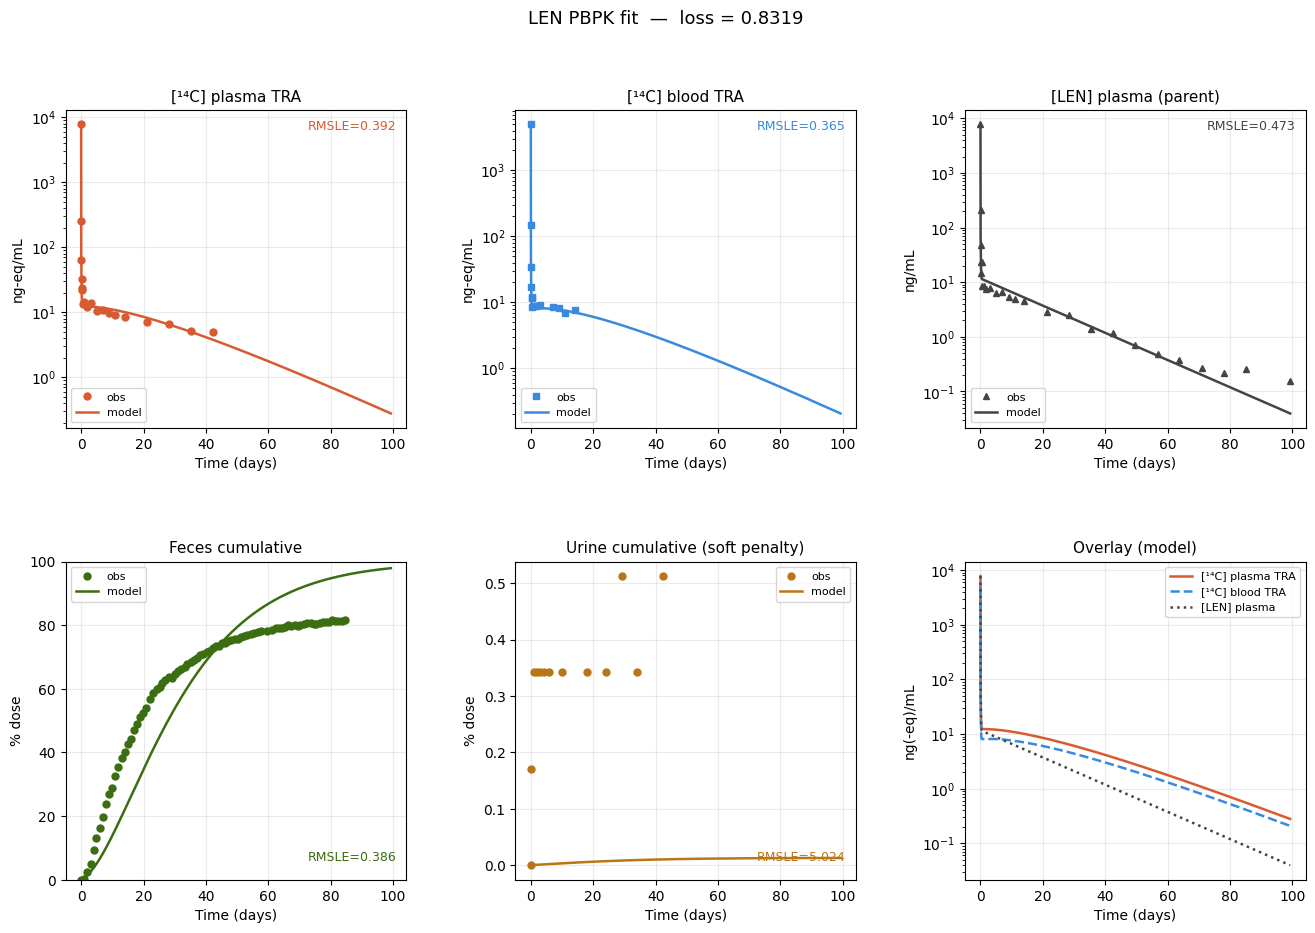

In [16]:
t_d = T_EVAL / 24

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

# 1. [14C] Plasma TRA
ax1 = fig.add_subplot(gs[0,0])
ax1.semilogy(t_pTRA/24, obs_pTRA, "o", color="#D85A30", ms=5, label="obs")
ax1.semilogy(t_d,       pTRA_fit, "-", color="#D85A30", lw=1.8, label="model")
ax1.set_title("[¹⁴C] plasma TRA", fontsize=11)
ax1.set_xlabel("Time (days)"); ax1.set_ylabel("ng-eq/mL")
ax1.text(0.97,0.97,f"RMSLE={r1:.3f}",transform=ax1.transAxes,ha="right",va="top",fontsize=9,color="#D85A30")
ax1.legend(fontsize=8); ax1.grid(alpha=0.25)

# 2. [14C] Blood TRA
ax2 = fig.add_subplot(gs[0,1])
ax2.semilogy(t_bTRA/24, obs_bTRA, "s", color="#378ADD", ms=5, label="obs")
ax2.semilogy(t_d,       bTRA_fit, "-", color="#378ADD", lw=1.8, label="model")
ax2.set_title("[¹⁴C] blood TRA", fontsize=11)
ax2.set_xlabel("Time (days)"); ax2.set_ylabel("ng-eq/mL")
ax2.text(0.97,0.97,f"RMSLE={r2:.3f}",transform=ax2.transAxes,ha="right",va="top",fontsize=9,color="#378ADD")
ax2.legend(fontsize=8); ax2.grid(alpha=0.25)

# 3. [LEN] Plasma
ax3 = fig.add_subplot(gs[0,2])
ax3.semilogy(t_LEN/24, obs_LEN, "^", color="#444441", ms=5, label="obs")
ax3.semilogy(t_d,      LEN_fit, "-", color="#444441", lw=1.8, label="model")
ax3.set_title("[LEN] plasma (parent)", fontsize=11)
ax3.set_xlabel("Time (days)"); ax3.set_ylabel("ng/mL")
ax3.text(0.97,0.97,f"RMSLE={r3:.3f}",transform=ax3.transAxes,ha="right",va="top",fontsize=9,color="#444441")
ax3.legend(fontsize=8); ax3.grid(alpha=0.25)

# 4. Feces cumulative
ax4 = fig.add_subplot(gs[1,0])
ax4.plot(t_fec/24, obs_fec, "o", color="#3B6D11", ms=5, label="obs")
ax4.plot(t_d,      fec_fit, "-", color="#3B6D11", lw=1.8, label="model")
ax4.set_title("Feces cumulative", fontsize=11)
ax4.set_xlabel("Time (days)"); ax4.set_ylabel("% dose")
ax4.set_ylim(0, 100)
ax4.text(0.97,0.05,f"RMSLE={r4:.3f}",transform=ax4.transAxes,ha="right",va="bottom",fontsize=9,color="#3B6D11")
ax4.legend(fontsize=8); ax4.grid(alpha=0.25)

# 5. Urine cumulative
ax5 = fig.add_subplot(gs[1,1])
ax5.plot(t_uri/24, obs_uri, "o", color="#BA7517", ms=5, label="obs")
ax5.plot(t_d,      uri_fit, "-", color="#BA7517", lw=1.8, label="model")
ax5.set_title("Urine cumulative (soft penalty)", fontsize=11)
ax5.set_xlabel("Time (days)"); ax5.set_ylabel("% dose")
ax5.text(0.97,0.05,f"RMSLE={r5:.3f}",transform=ax5.transAxes,ha="right",va="bottom",fontsize=9,color="#BA7517")
ax5.legend(fontsize=8); ax5.grid(alpha=0.25)

# 6. Overlay
ax6 = fig.add_subplot(gs[1,2])
ax6.semilogy(t_d, pTRA_fit, "-",  color="#D85A30", lw=1.8, label="[¹⁴C] plasma TRA")
ax6.semilogy(t_d, bTRA_fit, "--", color="#378ADD", lw=1.8, label="[¹⁴C] blood TRA")
ax6.semilogy(t_d, LEN_fit,  ":",  color="#444441", lw=1.8, label="[LEN] plasma")
ax6.set_title("Overlay (model)", fontsize=11)
ax6.set_xlabel("Time (days)"); ax6.set_ylabel("ng(-eq)/mL")
ax6.legend(fontsize=8); ax6.grid(alpha=0.25)

plt.suptitle(f"LEN PBPK fit  —  loss = {total:.4f}", fontsize=13, fontweight="500")
plt.tight_layout()
plt.show()


631 631


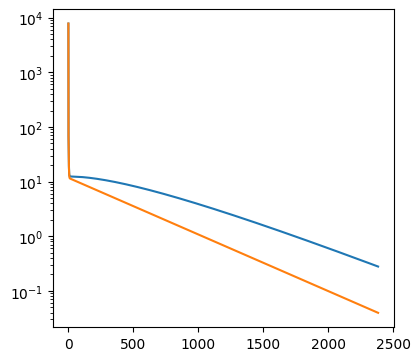

4349.655287983283 6322.173382103273 68.80000001733947


In [17]:
pTRA_fit, bTRA_fit, LEN_fit, fec_fit, uri_fit = get_obs(sol_fit, RBP_P_fit)
print(len(pTRA_fit), len(LEN_fit))
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)
ax1 = fig.add_subplot(gs[0,0])
ax1.semilogy(T_EVAL, pTRA_fit)
ax1.semilogy(T_EVAL, LEN_fit)
plt.show()
AUCr=np.trapezoid(pTRA_fit[0:300], T_EVAL[0:300])
AUCu=np.trapezoid(LEN_fit[0:300], T_EVAL[0:300])
R=AUCu/AUCr*100
print(AUCu, AUCr, R)